In [ ]:
#|default_exp sgd

# Accelerated SGD

In [ ]:
import sys
sys.path.insert(0, '/app/data/deeplearning/course22p2_zh/')

In [ ]:
import sys
sys.path.insert(0, '/app/data/deeplearning/course22p2_zh/')

In [ ]:
#|export
import torch

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

In [ ]:
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

In [ ]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)

import logging
logging.disable(logging.WARNING)

set_seed(42)

In [ ]:
xl,yl = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

bs = 1024
xmean,xstd = 0.28, 0.35

@inplace
def transformi(b): b[xl] = [(TF.to_tensor(o)-xmean)/xstd for o in b[xl]]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

In [ ]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
lrf_cbs = [DeviceCB(), LRFinderCB()]

## Optimizers

### SGD

In [ ]:
class SGD:
    def __init__(self, params, lr, wd=0.):
        params = list(params)
        fc.store_attr()
        self.i = 0

    def step(self):
        with torch.no_grad():
            for p in self.params:
                self.reg_step(p)
                self.opt_step(p)
        self.i +=1

    def opt_step(self, p): p -= p.grad * self.lr
    def reg_step(self, p):
        if self.wd != 0: p *= 1 - self.lr*self.wd

    def zero_grad(self):
        for p in self.params: p.grad.data.zero_()

In [ ]:
MomentumLearner??


````python
class MomentumLearner(TrainLearner):
    def __init__(self, model, dls, loss_func, lr=None, cbs=None, opt_func=optim.SGD, mom=0.85):
        self.mom = mom
        super().__init__(model, dls, loss_func, lr, cbs, opt_func)

    def zero_grad(self):
        with torch.no_grad():
            for p in self.model.parameters(): p.grad *= self.mom
````

**File:** `~/deeplearning/course22p2_zh/miniai/learner.py`

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs, opt_func=SGD)

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

accuracy,loss,epoch,train
0.802,0.542,0,train
0.848,0.416,0,eval
0.872,0.348,1,train
0.871,0.352,1,eval
0.887,0.307,2,train
0.860,0.394,2,eval


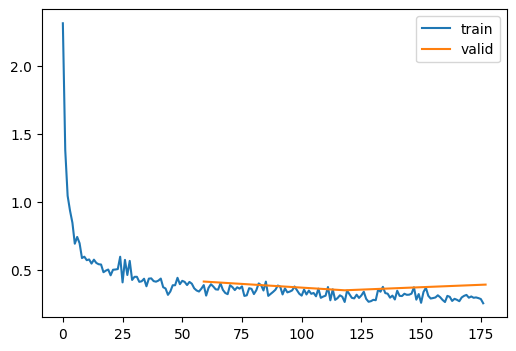

In [ ]:
learn.fit(3)

accuracy,loss,epoch,train
0.903,0.265,0,train
0.886,0.314,0,eval
0.908,0.253,1,train
0.889,0.308,1,eval


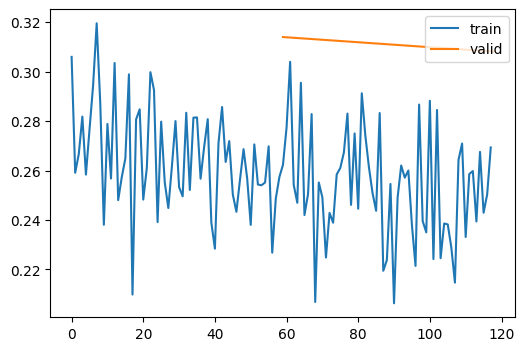

In [ ]:
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.05, cbs=cbs, opt_func=SGD)
learn.fit(2)

Consider the difference between *weight decay* and *L2 regularization*:

``` python
weight -= lr*wd*weight
```

...vs...

``` python
weight.grad += wd*weight
```

### Momentum

In [ ]:
xs = torch.linspace(-4, 4, 100)
ys = 1 - (xs/3) ** 2 + torch.randn(100) * 0.1

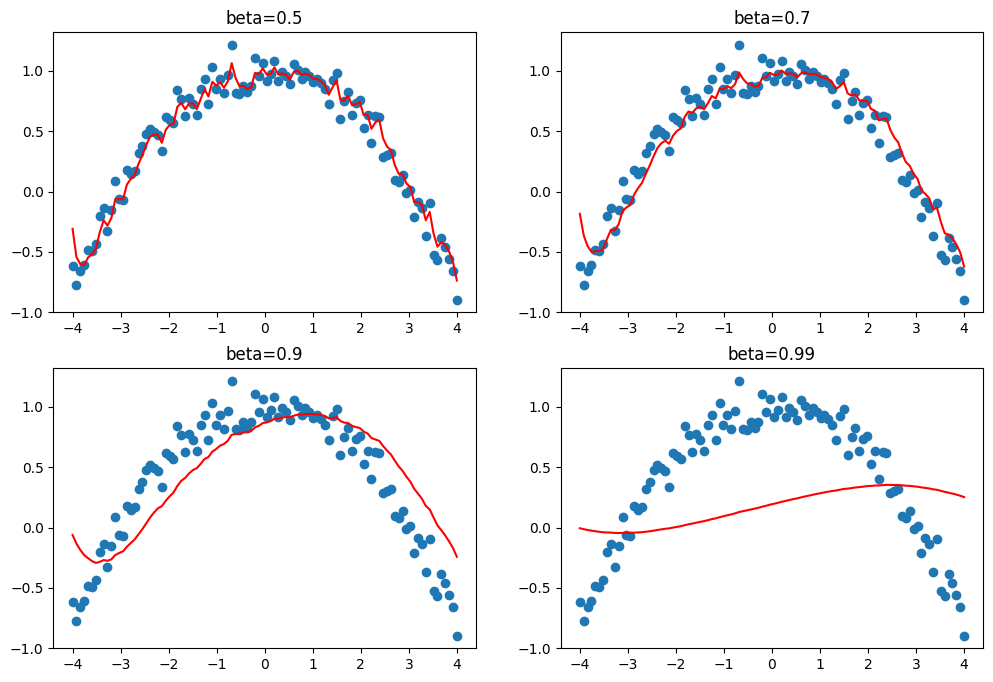

In [ ]:
_,axs = plt.subplots(2,2, figsize=(12,8))
betas = [0.5,0.7,0.9,0.99]
for beta,ax in zip(betas, axs.flatten()):
    ax.scatter(xs,ys)
    avg,res = 0,[]
    for yi in ys:
        avg = beta*avg + (1-beta)*yi
        res.append(avg)
    ax.plot(xs,np.array(res), color='red');
    ax.set_title(f'beta={beta}')

In [ ]:
class Momentum(SGD):
    def __init__(self, params, lr, wd=0., mom=0.9):
        super().__init__(params, lr=lr, wd=wd)
        self.mom=mom

    def opt_step(self, p):
        if not hasattr(p, 'grad_avg'): p.grad_avg = torch.zeros_like(p.grad)
        p.grad_avg = p.grad_avg*self.mom + p.grad*(1-self.mom)
        p -= self.lr * p.grad_avg

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=1.5, cbs=cbs, opt_func=Momentum)

accuracy,loss,epoch,train
0.788,0.586,0,train
0.847,0.423,0,eval
0.866,0.368,1,train
0.866,0.377,1,eval


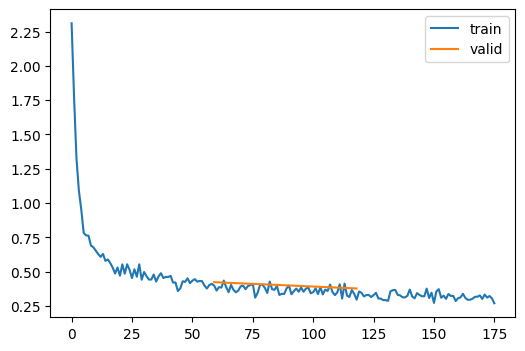

In [ ]:
learn.fit(3)

In [ ]:
learn = TrainLearner(model, dls, F.cross_entropy, lr=0.01, cbs=cbs, opt_func=Momentum)
learn.fit(2)

In [ ]:
astats.color_dim()

In [ ]:
clean_mem()

### RMSProp

In [ ]:
class RMSProp(SGD):
    def __init__(self, params, lr, wd=0., sqr_mom=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.sqr_mom,self.eps = sqr_mom,eps

    def opt_step(self, p):
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = p.grad**2
        p.sqr_avg = p.sqr_avg*self.sqr_mom + p.grad**2*(1-self.sqr_mom)
        p -= self.lr * p.grad/(p.sqr_avg.sqrt() + self.eps)

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=3e-3, cbs=cbs, opt_func=RMSProp)
learn.fit(3)

In [ ]:
astats.color_dim()

In [ ]:
clean_mem()

为什么RMSProp的学习率要设置这么小，不能像Moment一样

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！根本原因在于 **梯度被归一化后的尺度不同**。

## 有没有发现一个关键区别？

回顾一下两个优化器的更新公式：

**Momentum（动量 SGD）**
```
p -= lr * grad_avg
```
这里 `grad_avg` 保留了梯度的**原始大小**。如果梯度本身很小（比如 0.01），那每一步的实际移动就是 `lr × 0.01`。所以你可以把 lr 设到 0.01 甚至 1.5 —— 因为有梯度幅度的"天然衰减"。

**RMSProp**
```
p -= lr * grad / sqrt(sqr_avg + eps)
```
这里的 `grad / sqrt(sqr_avg)` 是**归一化后的值**。因为 `sqr_avg` 近似 `grad²`，所以这个比值大约就是 ±1（正负号决定方向）。换句话说，RMSProp 把梯度**压缩到了差不多 ±1 的量级**。

## 实际效果对比

| | 典型梯度幅度 | 有效步长 |
|--|--|--|
| Momentum | 0.01~0.1 | lr × (0.01~0.1) |
| RMSProp | ≈1（归一化后） | ≈ lr |

所以用 Momentum 时 lr=0.01，实际步长是 ~0.0001~0.001；用 RMSProp 时同样的 lr=0.01，实际步长是 ~0.01 —— **大了 10~100 倍**。这就是为什么 RMSProp（及其后继者 Adam）的默认学习率通常设在 1e-3 到 3e-4 这个量级，而 SGD/Momentum 可以用 0.01~0.1。

想试试把 RMSProp 的 lr 调到 0.01 或 0.1，看看会发生什么吗？

<details class='token-usage-details' markdown='1'><summary>$0.0018</summary>

`total=14,005 | in=12,962 | out=1,043 | cached=50.4% | reasoning=635 | searches=0 | $0.0018`

</details>


### Adam

In [ ]:
class Adam(SGD):
    def __init__(self, params, lr, wd=0., beta1=0.9, beta2=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.beta1,self.beta2,self.eps = beta1,beta2,eps

    def opt_step(self, p):
        if not hasattr(p, 'avg'): p.avg = torch.zeros_like(p.grad.data)
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)
        p.avg = self.beta1*p.avg + (1-self.beta1)*p.grad
        unbias_avg = p.avg / (1 - (self.beta1**(self.i+1)))
        p.sqr_avg = self.beta2*p.sqr_avg + (1-self.beta2)*(p.grad**2)
        unbias_sqr_avg = p.sqr_avg / (1 - (self.beta2**(self.i+1)))
        p -= self.lr * unbias_avg / (unbias_sqr_avg + self.eps).sqrt()

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=6e-3, cbs=cbs, opt_func=Adam)
learn.fit(3)

In [ ]:
clean_mem()

为什么Adaw中需要做unbias

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这个 bias correction 是为了解决 **初始化带来的偏差**。

## 问题出在哪？

`avg` 和 `sqr_avg` 都是从 0 开始初始化的：

```python
p.avg = torch.zeros_like(p.grad.data)       # ← 从 0 开始
p.sqr_avg = torch.zeros_like(p.grad.data)   # ← 从 0 开始
```

以 beta1=0.9 为例，看看前几步的 `avg` 会发生什么：

| 步数 | 期望的 EMA（大致） | 实际 avg | 偏差 |
|--|--|--|--|
| 第 1 步 | ≈ grad₁ | avg = 0.1·grad₁ | 只有真实值的 **10%** |
| 第 2 步 | ≈ 0.09·grad₁ + 0.9·grad₂ | avg = 0.09·grad₁ + 0.1·grad₂ | 第二项被严重低估 |
| 第 t 步 | ... | avg 偏小 | 早期显著 |

因为初始值是 0，前几步的移动平均被**拉向零**了——尤其是第一步，本来应该 ≈ grad₁，结果只有 0.1·grad₁。

## unbias 怎么修正？

```
unbias_avg = p.avg / (1 - beta1^(t+1))
```

分母就是"把缺失的比例补回来"：

| 步数 | 分母 | 效果 |
|--|--|--|
| 第 1 步 | 1 - 0.9¹ = 0.1 | 0.1·grad₁ / 0.1 = grad₁ ✅ |
| 第 2 步 | 1 - 0.9² = 0.19 | 补回第二项的权重 |
| 步数大时 | 1 - 0.9ᵗ ≈ 1 | 几乎不影响 |

随着 t 增大，`beta1^t` 趋于 0，分母趋于 1，修正自然消失。

## 一个小实验感受一下

可以试试跑一下这个，看看修正前后的差异：

```python
beta = 0.9
avg, unbias = 0, 0
for t in range(1, 6):
    avg = beta*avg + (1-beta)*1.0
    unbias = avg / (1 - beta**t)
    print(f"step {t}: avg={avg:.3f}, unbias={unbias:.3f}")
```

如果不做修正，Adam 在**前几步的步长会被人为缩小**，收敛速度会受影响。你会看到实际 fit 时，早期 loss 下降明显变慢。

<details class='token-usage-details' markdown='1'><summary>$0.0018</summary>

`total=15,288 | in=14,333 | out=955 | cached=53.6% | reasoning=357 | searches=0 | $0.0018`

</details>


In [ ]:
beta = 0.9
avg, unbias = 0, 0
for t in range(1, 6):
    avg = beta*avg + (1-beta)*1.0
    unbias = avg / (1 - beta**t)
    print(f"step {t}: avg={avg:.3f}, unbias={unbias:.3f}")

那为什么一定要从0开始初始化，不像单纯的Momentum和RMSProp版本一样初始化

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好眼力！你发现了一个关键区别：

## 两者的初始化对比

```python
# RMSProp —— 用 grad² 初始化
if not hasattr(p, 'sqr_avg'): p.sqr_avg = p.grad**2

# Adam —— 用 0 初始化
if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)
```

## 为什么 RMSProp 不能也用 0 初始化？

如果没有 bias correction，`sqr_avg` 从 0 开始的话，看看第一步：

```
beta2 = 0.99
第一步: sqr_avg = 0.99*0 + 0.01*grad² = 0.01·grad²
```

那更新步长就变成了：
```
lr * grad / sqrt(0.01·grad² + eps) ≈ lr * grad / (0.1·|grad|) = lr * sign(grad) / 0.1
```

相当于步长被放大了 **10 倍**！这非常不稳定。所以简单的 RMSProp 用 `grad²` 做初始化，跳过这个坑。

## Adam 为什么可以？

因为 Adam 有 `unbias_sqr_avg = p.sqr_avg / (1 - beta2^(t+1))` 这个修正。

对第一步来说：
```
sqr_avg = 0.01·grad²
unbias_sqr_avg = 0.01·grad² / (1 - 0.99¹) = 0.01·grad² / 0.01 = grad² ✅
```

修正正好把那个 0.01 的衰减补回来了，结果 ≈ `grad²`，效果和 RMSProp 的直接初始化一样。

所以总结就是：**bias correction 让 Adam 可以从零开始，而简单的 RMSProp 没有这层修正，只能靠实际值初始化来避免第一步爆炸。**

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=16,597 | in=15,222 | out=1,375 | cached=83.2% | reasoning=950 | searches=0 | $0.0011`

</details>


那么单纯Momentun的版本呢

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题，我们来仔细看看 Momentum 的定义：

```python
class Momentum(SGD):
    def opt_step(self, p):
        if not hasattr(p, 'grad_avg'): p.grad_avg = torch.zeros_like(p.grad)  # ← 也是从 0 开始！
        p.grad_avg = p.grad_avg*self.mom + p.grad*(1-self.mom)
        p -= self.lr * p.grad_avg
```

你猜怎么着？**Momentum 其实也是从 0 初始化的**，而且**没有 bias correction**！

## 为什么 Momentum 不需要修正？

关键在于 **这两种情况对学习率的敏感度完全不同**：

| | 初始化偏差 | 后果 |
|--|--|--|
| **Momentum** | 第一步 `grad_avg = 0.1·grad` | 步长变成 `lr × 0.1·grad` —— **偏小**，只是变慢一点而已 |
| **RMSProp**（如果用 0 初始化） | 第一步 `sqr_avg = 0.01·grad²` | 步长变成 `lr × grad / (0.1·\|grad\|)` —— **放大了 10 倍**，可能直接爆炸 |

Momentum 的偏差是让 **第一步偏小** —— 往后几步就追上来了，因为 `grad_avg` 会快速累积真实梯度。实际训练时这反而有点好处：**隐式地实现了 warm-up**（前几步步子小一点），对训练稳定性有积极作用。

RMSProp/Adam 的偏差就危险了 —— 用 0 初始化分母的话，**第一步除以一个很小的数**，步长直接放大，可能导致 loss 瞬间炸掉。

所以简单来说：**乘小没事，除小要命**。

<details class='token-usage-details' markdown='1'><summary>$0.0007</summary>

`total=16,620 | in=15,709 | out=911 | cached=89.6% | reasoning=515 | searches=0 | $0.0007`

</details>


## Schedulers

We've already seen how we can easily write a custom LR-adjusting callback or `Learner`, or can use the predefined PyTorch schedulers. We'll use the predefined ones for now since there's nothing new to learn in implementing them ourselves.

In [ ]:
' '.join(o for o in dir(lr_scheduler) if o[0].isupper() and o[1].islower())

'ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau SequentialLR StepLR'

In [ ]:
' '.join(filter(lambda x: x[0].isupper() and x[1].islower(), dir(lr_scheduler)))

'ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau SequentialLR StepLR'

In [ ]:
learn = TrainLearner(get_model(), dls, F.cross_entropy, lr=6e-3, cbs=[DeviceCB(), SingleBatchCB()])
learn.fit(1)

In [ ]:
opt = learn.opt
' '.join(o for o in dir(opt) if o[0]!='_')

'add_param_group defaults load_state_dict param_groups state state_dict step zero_grad'

In [ ]:
opt

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.006
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
param = next(iter(learn.model.parameters()))
st = opt.state[param]

In [ ]:
st

{'momentum_buffer': None}

In [ ]:
len(opt.param_groups)

1

In [ ]:
pg = opt.param_groups[0]

In [ ]:
list(pg)

['params',
 'lr',
 'momentum',
 'dampening',
 'weight_decay',
 'nesterov',
 'maximize',
 'foreach',
 'differentiable']

In [ ]:
sched = lr_scheduler.CosineAnnealingLR(opt, 100)

In [ ]:
sched.base_lrs

[0.006]

In [ ]:
sched.get_last_lr()

[0.006]

In [ ]:
def sched_lrs(sched, steps):
    lrs = [sched.get_last_lr()]
    for i in range(steps):
        sched.optimizer.step()
        sched.step()
        lrs.append(sched.get_last_lr())
    plt.plot(lrs)

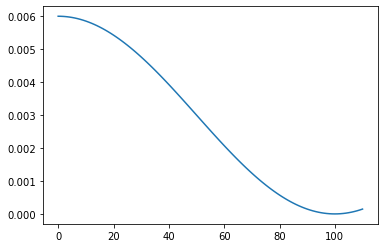

In [ ]:
sched_lrs(sched, 110)

### Scheduler callbacks

In [ ]:
#|export
class BaseSchedCB(Callback):
    def __init__(self, sched): self.sched = sched
    def before_fit(self, learn): self.schedo = self.sched(learn.opt)
    def _step(self, learn):
        if learn.training: self.schedo.step()

In [ ]:
#|export
class BatchSchedCB(BaseSchedCB):
    def after_batch(self, learn): self._step(learn)

In [ ]:
#|export
class HasLearnCB(Callback):
    def before_fit(self, learn): self.learn = learn 
    def after_fit(self, learn): self.learn = None

In [ ]:
#|export
class RecorderCB(Callback):
    def __init__(self, **d): self.d = d
    def before_fit(self, learn):
        self.recs = {k:[] for k in self.d}
        self.pg = learn.opt.param_groups[0]
    
    def after_batch(self, learn):
        if not learn.training: return
        for k,v in self.d.items():
            self.recs[k].append(v(self))

    def plot(self):
        for k,v in self.recs.items():
            plt.plot(v, label=k)
            plt.legend()
            plt.show()

In [ ]:
def _lr(cb): return cb.pg['lr']

In [ ]:
len(dls.train)

59

In [ ]:
tmax = 3 * len(dls.train)
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=tmax)

accuracy,loss,epoch,train
0.809,0.515,0,train
0.858,0.383,0,eval
0.881,0.327,1,train
0.874,0.339,1,eval
0.898,0.280,2,train
0.883,0.317,2,eval


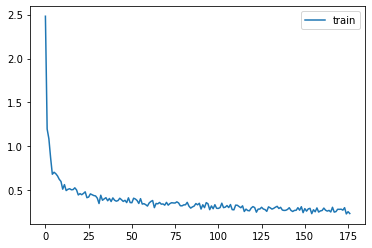

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
rec = RecorderCB(lr=_lr)
xtra = [BatchSchedCB(sched),rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(3)

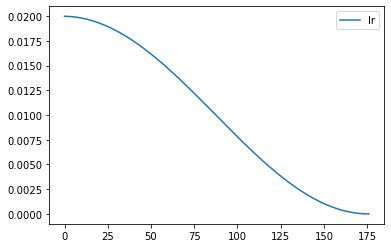

In [ ]:
rec.plot()

In [ ]:
#|export
class EpochSchedCB(BaseSchedCB):
    def after_epoch(self, learn): self._step(learn)

accuracy,loss,epoch,train
0.809,0.517,0,train
0.857,0.382,0,eval
0.881,0.327,1,train
0.875,0.339,1,eval
0.899,0.275,2,train
0.887,0.307,2,eval


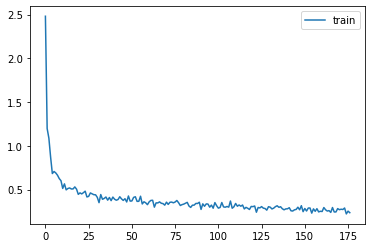

In [ ]:
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=3)
set_seed(42)
xtra = [EpochSchedCB(sched),rec]
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(3)

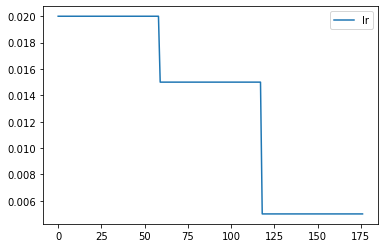

In [ ]:
rec.plot()

### 1cycle training

[Paper](https://arxiv.org/abs/1803.09820) by Leslie Smith.

In [ ]:
def _beta1(cb): return cb.pg['betas'][0]
rec = RecorderCB(lr=_lr, mom=_beta1)

accuracy,loss,epoch,train
0.765,0.662,0,train
0.822,0.546,0,eval
0.862,0.376,1,train
0.856,0.413,1,eval
0.888,0.304,2,train
0.879,0.333,2,eval
0.904,0.257,3,train
0.901,0.279,3,eval
0.924,0.210,4,train
0.906,0.267,4,eval


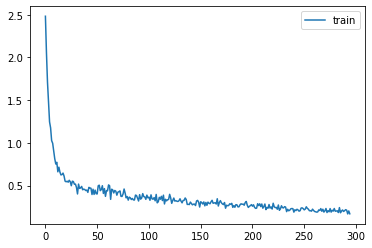

In [ ]:
set_seed(42)
lr,epochs = 6e-2,5
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched), rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(epochs)

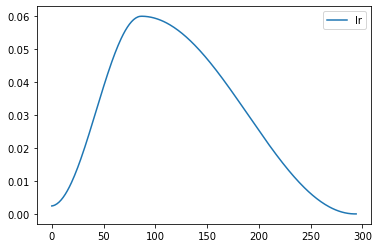

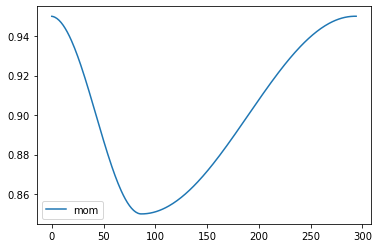

In [ ]:
rec.plot()

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()